<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/C6_Regime_Classification_and_Indexing_Protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C6 Notebook started

Simulation complete. Detected 4 regimes.



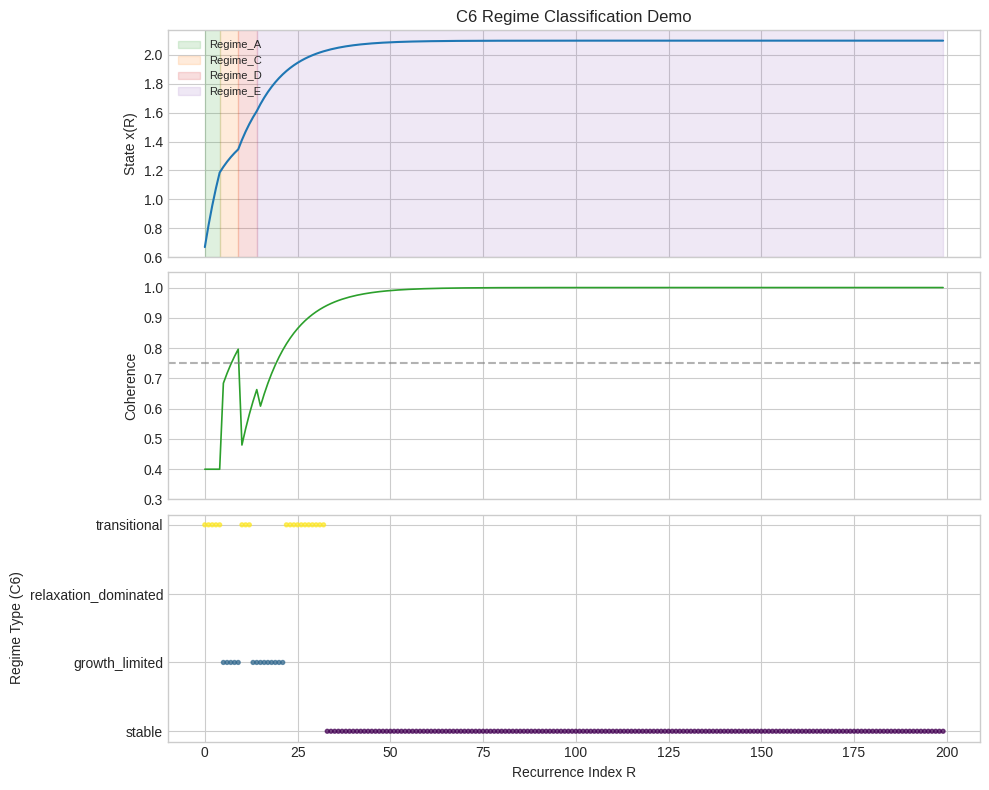

=== Regime Summary ===
  Regime_A: started at R = 0
  Regime_C: started at R = 4
  Regime_D: started at R = 9
  Regime_E: started at R = 14


In [ ]:
# ============================================================
# C6 Regime Classification and Indexing Protocol
# Clean single-file version for Colab (iPad friendly)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Parameters
R_max = 200
alpha = 0.08
tau_base = 12.0
h3pi_threshold = 0.035

print("C6 Notebook started\n")

# Core operators
def sqrt2_transport(x, R, alpha=alpha):
    growth = alpha * (1.0 - np.tanh(x / 3.0))
    return x + growth

def hHRT_relax(x, x_eq, tau):
    return x + (x_eq - x) / tau

def coupled_step(x, R, x_eq, alpha, tau):
    x_new = sqrt2_transport(x, R, alpha)
    x_new = hHRT_relax(x_new, x_eq, tau)
    return x_new

# Regime classification (C6)
@dataclass
class Regime:
    label: str
    start_R: int

def classify_regime(x, dx, coherence):
    if abs(dx) < 0.008 and coherence > 0.85:
        return "stable"
    elif dx > 0.025 and coherence > 0.6:
        return "growth_limited"
    elif abs(dx) < 0.015 and coherence < 0.75:
        return "relaxation_dominated"
    else:
        return "transitional"

# Simplified h3pi detection
def detect_regime_crossing(residuals, threshold=h3pi_threshold):
    if len(residuals) < 5:
        return False
    recent = np.array(residuals[-5:])
    structured_dev = np.std(recent) + np.mean(np.abs(recent))
    return structured_dev > threshold

# Minimal re-indexing
def minimal_reindex(current_regime, new_label, R):
    return Regime(label=new_label, start_R=R)

# Main simulation
def run_c6_simulation():
    x = 0.5
    x_eq = 1.8
    tau = tau_base
    history = []
    regimes = [Regime(label="Regime_A", start_R=0)]
    current_regime = regimes[0]
    residuals = []

    for R in range(R_max):
        x_new = coupled_step(x, R, x_eq, alpha, tau)
        dx = x_new - x
        coherence = max(0.4, 1.0 - abs(dx) * 8)
        regime_type = classify_regime(x_new, dx, coherence)

        residuals.append(dx)
        crossing = detect_regime_crossing(residuals)

        if crossing and len(regimes) < 4:
            new_label = f"Regime_{chr(66 + len(regimes))}"
            new_regime = minimal_reindex(current_regime, new_label, R)
            regimes.append(new_regime)
            current_regime = new_regime
            residuals = []
            x_eq = x_new + np.random.uniform(-0.3, 0.3)

        history.append({
            'R': R,
            'x': x_new,
            'dx': dx,
            'coherence': coherence,
            'regime_type': regime_type,
            'regime_label': current_regime.label
        })
        x = x_new

    return history, regimes

history, regimes = run_c6_simulation()
print(f"Simulation complete. Detected {len(regimes)} regimes.\n")

# Plot results
def plot_c6_results(history, regimes):
    R = [h['R'] for h in history]
    x = [h['x'] for h in history]
    coherence = [h['coherence'] for h in history]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(R, x, color='#1f77b4', linewidth=1.5)
    axes[0].set_ylabel('State x(R)')
    axes[0].set_title('C6 Regime Classification Demo')

    colors_reg = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
    for i, reg in enumerate(regimes):
        start = reg.start_R
        end = regimes[i+1].start_R if i+1 < len(regimes) else R[-1]
        axes[0].axvspan(start, end, alpha=0.15, color=colors_reg[i % len(colors_reg)], label=reg.label)
    axes[0].legend(loc='upper left', fontsize=8)

    axes[1].plot(R, coherence, color='#2ca02c', linewidth=1.2)
    axes[1].axhline(y=0.75, color='gray', linestyle='--', alpha=0.6)
    axes[1].set_ylabel('Coherence')
    axes[1].set_ylim(0.3, 1.05)

    regime_map = {'stable': 0, 'growth_limited': 1, 'relaxation_dominated': 2, 'transitional': 3}
    regime_num = [regime_map.get(h['regime_type'], 3) for h in history]
    axes[2].scatter(R, regime_num, c=regime_num, cmap='viridis', s=8, alpha=0.7)
    axes[2].set_yticks([0,1,2,3])
    axes[2].set_yticklabels(['stable', 'growth_limited', 'relaxation_dominated', 'transitional'])
    axes[2].set_ylabel('Regime Type (C6)')
    axes[2].set_xlabel('Recurrence Index R')

    plt.tight_layout()
    plt.show()

    print("=== Regime Summary ===")
    for reg in regimes:
        print(f"  {reg.label}: started at R = {reg.start_R}")

plot_c6_results(history, regimes)